# 01. Exploration du jeu de données

Projet Air Paradis, prédiction du sentiment d'un tweet.

## Ce que je fais dans ce notebook

C'est le point de départ obligatoire du projet, et il sert à deux choses.

D'abord, comprendre les données avant de modéliser quoi que ce soit. On ne
choisit pas une architecture de modèle au hasard : la longueur des tweets,
l'équilibre entre les classes et le vocabulaire employé décident directement
des réglages des modèles qui viendront après.

Ensuite, produire le fichier de travail partagé. Le nettoyage des 1,6 million
de tweets est fait ici, une seule fois, et sauvegardé sur le disque. Les trois
notebooks de modélisation repartent tous de ce même fichier, ce qui rend la
comparaison des trois approches honnête.

À exécuter avant les notebooks 02, 03 et 04.

## 1. Préparer l'environnement

La première cellule sert à un problème purement technique. Ce notebook est
rangé dans le dossier `notebooks/`, alors que le code que je partage entre
tous les notebooks est dans `src/`, un dossier au-dessus. Par défaut Python ne
va pas chercher là, donc je remonte l'arborescence jusqu'à trouver la racine
du projet et je l'ajoute à la liste des endroits où Python cherche ses
modules.

Je repère la racine grâce à la présence du fichier `pytest.ini`. Je fais comme
ça plutôt que d'écrire `".."` en dur, pour que le notebook marche quel que
soit l'endroit d'où Jupyter a été lancé.

In [1]:
import sys
from pathlib import Path

RACINE_PROJET = next(
    dossier
    for dossier in [Path.cwd(), *Path.cwd().parents]
    if (dossier / "pytest.ini").exists()
)

if str(RACINE_PROJET) not in sys.path:
    sys.path.insert(0, str(RACINE_PROJET))

print(f"Racine du projet : {RACINE_PROJET}")

Racine du projet : C:\Users\dwyts\Documents\PROJET7 Openclassrooms


In [2]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config
from src.data_loader import charger_donnees_brutes, formater_nombre, preparer_donnees
from src.preprocessing import nettoyer_tweet, retirer_mots_vides

# Réglages d'affichage : des graphiques lisibles et des colonnes de texte
# qui ne sont pas coupées au milieu.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 120)

print("Bibliothèques chargées.")

Bibliothèques chargées.


## 2. Charger les données brutes

Le jeu de données s'appelle Sentiment140. Il contient 1 600 000 tweets en
anglais collectés en 2009.

Sa particularité, c'est la façon dont il a été étiqueté : automatiquement.
Un tweet qui contenait une émoticône souriante a été classé positif, un tweet
avec une émoticône triste a été classé négatif. Les émoticônes ont ensuite été
retirées du texte, pour que le modèle ne puisse pas tricher en les repérant.

Cette méthode a une conséquence qu'il faut garder en tête pour tout le reste
du projet : les étiquettes sont bruitées. Un tweet ironique accompagné d'un
smiley se retrouve étiqueté positif alors qu'il ne l'est pas. C'est une limite
du jeu de données lui-même, et elle impose un plafond de performance qu'aucun
modèle ne pourra dépasser.

In [3]:
donnees_brutes = charger_donnees_brutes()

Lecture de : training.1600000.processed.noemoticon.csv


  1 600 000 tweets charges
  Negatifs : 800 000
  Positifs : 800 000


In [4]:
donnees_brutes.head(10)

,texte,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",0
1,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,0
2,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",0
5,@Kwesidei not the whole crew,0
6,Need a hug,0
7,"@LOLTrish hey long time no see! Yes.. Rains a bit ,only a bit LOL , I'm fine thanks , how's you ?",0
8,@Tatiana_K nope they didn't have it,0
9,@twittera que me muera ?,0


## 3. Qualité et équilibre du jeu de données

Deux vérifications de routine avant de modéliser.

Les valeurs manquantes d'abord : un texte vide fausserait l'entraînement.

L'équilibre des classes ensuite. Une classe, ici, c'est simplement une des
deux réponses possibles : négatif ou positif. Si l'une des deux dominait
largement, l'exactitude deviendrait une mesure trompeuse. L'exactitude est la
part de réponses justes : sur un jeu où 95 % des tweets seraient positifs, un
modèle qui répondrait toujours "positif" afficherait 95 % d'exactitude sans
avoir rien appris.

La question des doublons est traitée plus loin, en section 6, parce que c'est
après le nettoyage qu'elle devient vraiment visible.

In [5]:
print("Valeurs manquantes par colonne :")
print(donnees_brutes.isna().sum())

Valeurs manquantes par colonne :
texte    0
label    0
dtype: int64


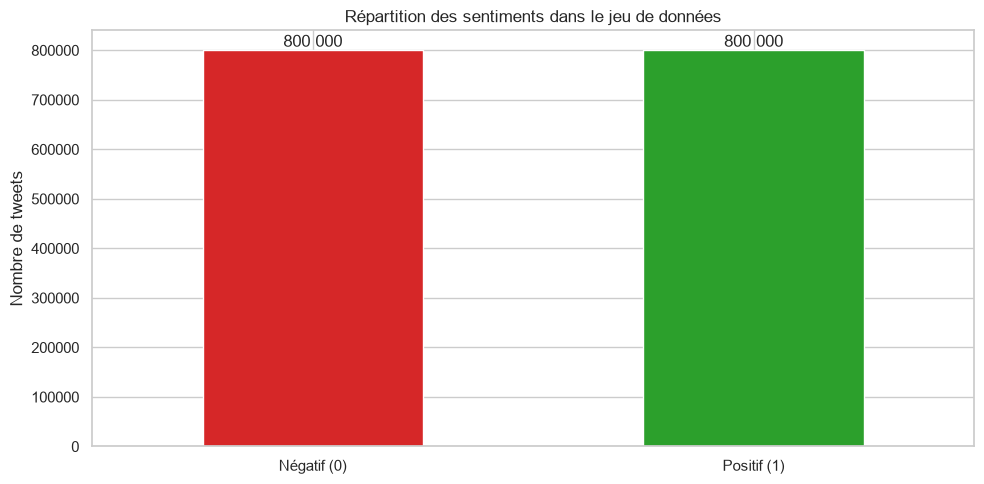

Négatif (0)    800000
Positif (1)    800000
Name: count, dtype: int64


In [6]:
repartition = donnees_brutes["label"].value_counts().sort_index()
repartition.index = ["Négatif (0)", "Positif (1)"]

axe = repartition.plot(kind="bar", color=["#d62728", "#2ca02c"], rot=0)
axe.set_title("Répartition des sentiments dans le jeu de données")
axe.set_ylabel("Nombre de tweets")

# J'affiche la valeur exacte au-dessus de chaque barre.
for index, valeur in enumerate(repartition):
    axe.text(index, valeur, formater_nombre(valeur), ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(repartition)

### Ce que j'en retiens

Le jeu de données est parfaitement équilibré : 800 000 tweets de chaque côté.

Deux conséquences pratiques. L'exactitude est une mesure fiable ici, le piège
décrit plus haut n'existe pas. Et le hasard correspond à 50 %, c'est le
plancher : tout modèle doit faire nettement mieux pour avoir un intérêt.

Je vais quand même suivre plusieurs mesures en plus de l'exactitude, parce que
le besoin d'Air Paradis n'est pas symétrique. Rater un tweet négatif, c'est un
bad buzz qui démarre sans qu'on le voie venir. Signaler à tort un tweet
positif, c'est trente secondes de perdues pour un chargé de communication. Les
deux erreurs n'ont pas du tout le même coût.

## 4. Un échantillon pour l'analyse

Les sections qui suivent regardent le texte après nettoyage, parce que c'est
ça que le modèle verra vraiment. Le texte brut, lui, contient encore les liens
et les mentions.

Nettoyer les 1,6 million de tweets prend une minute. Pour explorer, un
échantillon de 200 000 tweets tiré au hasard suffit largement : les
proportions observées dessus sont fiables à moins de 0,3 % près. Le nettoyage
complet, lui, se fera une seule fois en section 8.

In [7]:
TAILLE_ECHANTILLON_ANALYSE = 200_000

echantillon = donnees_brutes.sample(
    TAILLE_ECHANTILLON_ANALYSE,
    random_state=config.GRAINE_ALEATOIRE,
).copy()

echantillon["texte_nettoye"] = echantillon["texte"].apply(nettoyer_tweet)

print(f"Échantillon d'analyse : {formater_nombre(len(echantillon))} tweets nettoyés")

Échantillon d'analyse : 200 000 tweets nettoyés


## 5. La longueur des tweets

Cette mesure n'est pas là pour faire joli, elle fixe directement un réglage du
modèle avancé, celui que j'ai appelé `LONGUEUR_MAX_SEQUENCE` dans
`src/config.py`.

Un réseau de neurones récurrent lit le tweet mot par mot, mais il a besoin que
tous les tweets fassent la même longueur. Il faut donc choisir un nombre de
mots.

Si je le prends trop court, les tweets longs sont coupés et je perds de
l'information. Si je le prends trop long, la plupart des tweets sont complétés
par des zéros inutiles, et le temps de calcul augmente pour rien, puisque le
coût d'un réseau récurrent est proportionnel à cette longueur.

Je compare exprès le texte brut et le texte nettoyé. C'est le second qui doit
servir de référence.

In [8]:
longueur_brute = echantillon["texte"].str.split().str.len()
longueur_nettoyee = echantillon["texte_nettoye"].str.split().str.len()

# Un quantile à 90 % veut dire : la valeur en dessous de laquelle se trouvent
# 90 % des tweets. C'est plus parlant que la moyenne pour dimensionner une
# limite, parce que la moyenne se laisse tirer par quelques tweets très longs.
print("Longueur en nombre de mots :\n")
print(f"{'Quantile':>10} | {'Texte brut':>12} | {'Texte nettoyé':>14}")
print("-" * 42)
for quantile in [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]:
    print(
        f"{quantile:>9.1%} | "
        f"{longueur_brute.quantile(quantile):>12.0f} | "
        f"{longueur_nettoyee.quantile(quantile):>14.0f}"
    )
print("-" * 42)
print(f"{'maximum':>10} | {longueur_brute.max():>12.0f} | {longueur_nettoyee.max():>14.0f}")

Longueur en nombre de mots :

  Quantile |   Texte brut |  Texte nettoyé
------------------------------------------
    50.0% |           12 |             12
    75.0% |           19 |             18
    90.0% |           23 |             23
    95.0% |           25 |             25
    99.0% |           28 |             28
    99.9% |           31 |             30
------------------------------------------
   maximum |           41 |             46


In [9]:
# Quelle part des tweets tient entièrement, selon la limite que je choisis ?
print("Part des tweets nettoyés gardés en entier, selon la limite :\n")
for seuil in [24, 28, 32, 40, 48]:
    couverture = (longueur_nettoyee <= seuil).mean()
    marque = "  <- la valeur que je retiens" if seuil == config.LONGUEUR_MAX_SEQUENCE else ""
    print(f"  limite {seuil:3d} mots  ->  {couverture:8.3%}{marque}")

Part des tweets nettoyés gardés en entier, selon la limite :

  limite  24 mots  ->   94.473%
  limite  28 mots  ->   99.484%
  limite  32 mots  ->   99.984%  <- la valeur que je retiens
  limite  40 mots  ->   99.999%
  limite  48 mots  ->  100.000%


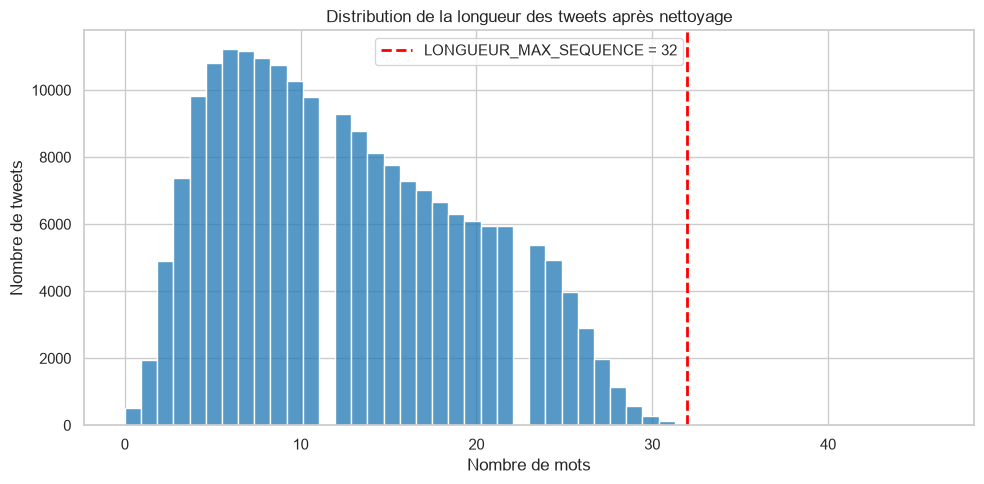

In [10]:
axe = sns.histplot(longueur_nettoyee, bins=50, color="#1f77b4")
axe.set_title("Distribution de la longueur des tweets après nettoyage")
axe.set_xlabel("Nombre de mots")
axe.set_ylabel("Nombre de tweets")

axe.axvline(
    config.LONGUEUR_MAX_SEQUENCE,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"LONGUEUR_MAX_SEQUENCE = {config.LONGUEUR_MAX_SEQUENCE}",
)
axe.legend()
plt.tight_layout()
plt.show()

### Ce que j'en retiens

Je retiens 32 mots, et le tableau du dessus explique pourquoi. Cette limite
garde 99,98 % des tweets en entier.

Passer de 40 à 32 mots réduit le temps d'entraînement du réseau récurrent
d'environ 20 %, et en échange je ne coupe la fin que de 15 tweets sur 100 000.
L'échange est clairement avantageux. C'est le genre de choix que je préfère
faire sur une mesure plutôt qu'au jugé.

## 6. Les doublons

Un point facile à négliger, et qui fausse pourtant le score final.

Le nettoyage supprime les liens et les mentions. Du coup, deux tweets qui ne
différaient que par le pseudo mentionné deviennent strictement identiques. Le
taux de doublons, faible sur le texte brut, monte donc nettement une fois le
nettoyage fait.

In [11]:
doublons_bruts = echantillon["texte"].duplicated().mean()
doublons_nettoyes = echantillon["texte_nettoye"].duplicated().mean()

print(f"Doublons sur le texte brut     : {doublons_bruts:.2%}")
print(f"Doublons sur le texte nettoyé  : {doublons_nettoyes:.2%}")

Doublons sur le texte brut     : 0.42%
Doublons sur le texte nettoyé  : 2.98%


In [12]:
print("Les textes nettoyés qui reviennent le plus souvent :\n")
print(echantillon["texte_nettoye"].value_counts().head(10).to_string())

Les textes nettoyés qui reviennent le plus souvent :

texte_nettoye
                                                                                   502
thanks                                                                             263
thank you                                                                          172
good morning                                                                       164
get followers a day using once you add everyone you are on the train or pay vip    161
me too                                                                              73
i am lost please help me find a good home                                           72
goodnight                                                                           65
i know                                                                              49
headache                                                                            44


### Pourquoi je les enlève

Il y a deux problèmes distincts, et les deux sont sérieux.

Le premier, c'est une fuite entre l'entraînement et le test. Une fuite, en
apprentissage automatique, c'est quand une information du jeu de test se
retrouve d'une façon ou d'une autre dans l'entraînement. Ici le découpage
entre les deux se fait au hasard, donc si un même texte apparaît 500 fois, il
va forcément se retrouver des deux côtés. Le modèle l'aura déjà vu pendant
l'entraînement, il le reconnaît au lieu de le comprendre, et le score du test
devient trop beau. Le modèle paraît meilleur qu'il ne le sera en production,
où il ne verra que des tweets nouveaux.

Le second, c'est du spam de robots. La liste juste au-dessus le montre bien :
on y trouve un message publicitaire automatique republié des centaines de
fois. Ce n'est pas du langage naturel, et le faire apprendre au modèle n'a
aucun intérêt.

Ce que je décide : dédupliquer sur le texte nettoyé, en gardant la première
occurrence. Je perds environ 5 % des lignes, ce qui n'a aucune importance avec
1,6 million de tweets, et je gagne une évaluation honnête. C'est ce que fait
la fonction `preparer_donnees()` en section 8.

## 7. Le nettoyage et le vocabulaire des classes

### 7.1 Ce que fait concrètement le nettoyage

Je regarde ici, sur des exemples réels, ce que fait `src/preprocessing.py` :
supprimer les liens et les mentions, décoder les entités HTML (les codes
comme `&amp;` que le web utilise pour écrire un `&`), réduire les lettres
répétées, enlever la ponctuation.

La colonne "sans mots vides" montre une étape supplémentaire que je réserve au
modèle classique. Les mots vides sont les mots trop courants pour porter du
sens tout seuls : les articles, les pronoms, les auxiliaires.

J'en profite pour vérifier le point le plus important du prétraitement : que
les négations survivent.

In [13]:
exemples = echantillon.sample(8, random_state=config.GRAINE_ALEATOIRE)

comparaison = pd.DataFrame({
    "Brut": exemples["texte"],
    "Nettoyé": exemples["texte_nettoye"],
    "Sans mots vides": exemples["texte_nettoye"].apply(retirer_mots_vides),
})

comparaison.reset_index(drop=True)

,Brut,Nettoyé,Sans mots vides
0,@McFLYFan_Katie listening to wonderful music. I'd like to have holidays now. xx,listening to wonderful music i'd like to have holidays now xx,listening wonderful music i'd like holidays xx
1,is watching angels and demons &lt;3 for free at http://FreeTheaters.com.,is watching angels and demons for free at,watching angels demons free
2,spending time with my baby girl...before she goes off to college.,spending time with my baby girl before she goes off to college,spending time baby girl goes college
3,I know you all too well,i know you all too well,know too
4,"@Burnt_feet hahaha cheers! I won't forget that in the exam now! I love how me, you and @sopho_suave have these chats...",hahaha cheers i won't forget that in the exam now i love how me you and have these chats before history exams,hahaha cheers won't forget exam love chats history exams
5,"@TomineeeHarket night nights..you will be just fine, dont worry...oh shoot, i should really sleep too",night nights you will be just fine dont worry oh shoot i should really sleep too,night nights fine dont worry oh shoot really sleep too
6,@biz But a great day,but a great day,but great day
7,FML jeanette mccurdy from iCarly is almost 3 months older than me,fml jeanette mccurdy from icarly is almost months older than me,fml jeanette mccurdy icarly almost months older


In [14]:
# Vérification ciblée sur la négation.
cas_de_test = [
    "@AirParadis the flight was NOT good at all!!! #disappointed http://t.co/xyz",
    "Best crew ever, sooooo friendly &amp; helpful :)",
]

for texte in cas_de_test:
    print(f"Brut            : {texte}")
    print(f"Nettoyé         : {nettoyer_tweet(texte)}")
    print(f"Sans mots vides : {retirer_mots_vides(nettoyer_tweet(texte))}")
    print("-" * 100)

Brut            : @AirParadis the flight was NOT good at all!!! #disappointed http://t.co/xyz
Nettoyé         : the flight was not good at all disappointed
Sans mots vides : flight not good disappointed
----------------------------------------------------------------------------------------------------
Brut            : Best crew ever, sooooo friendly &amp; helpful :)
Nettoyé         : best crew ever soo friendly and helpful
Sans mots vides : best crew ever soo friendly helpful
----------------------------------------------------------------------------------------------------


### 7.2 Est-ce que le signal existe ?

Question préalable indispensable : les deux classes emploient-elles un
vocabulaire différent ?

Si elles utilisaient exactement les mêmes mots, une approche qui se contente
de compter les mots serait condamnée d'avance, et il faudrait passer
directement aux modèles qui tiennent compte du contexte.

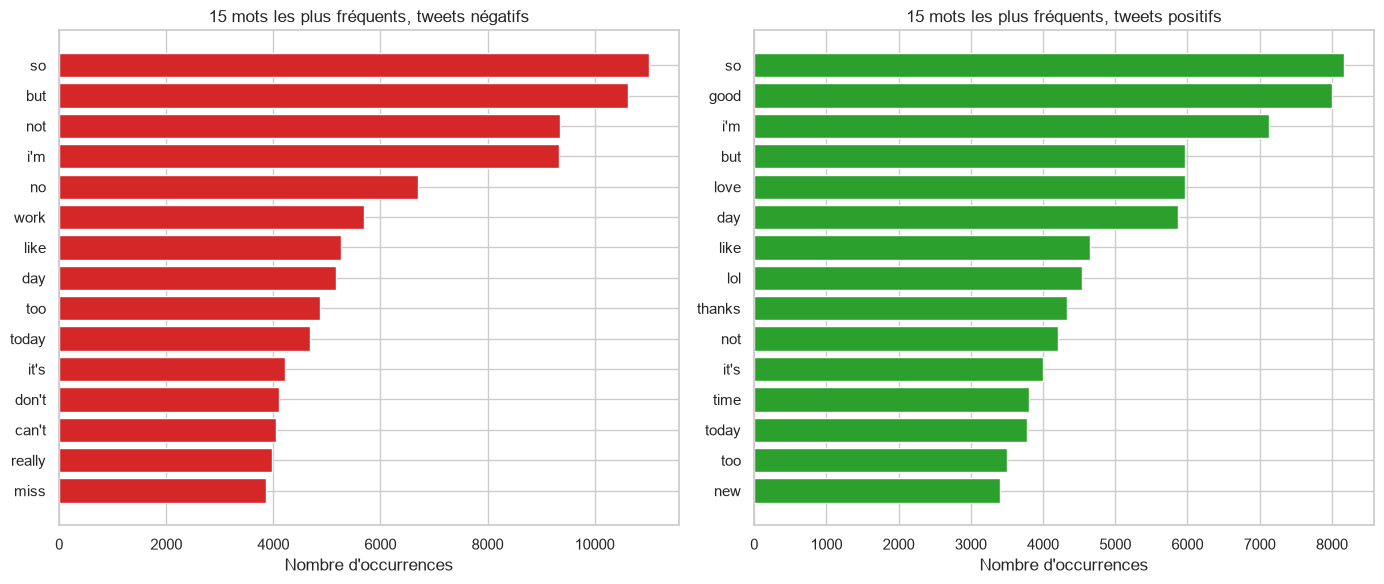

In [15]:
compteurs = {}
for valeur_label, nom_classe in [(0, "Négatif"), (1, "Positif")]:
    textes = echantillon.loc[echantillon["label"] == valeur_label, "texte_nettoye"]
    mots = " ".join(textes.apply(retirer_mots_vides)).split()
    compteurs[nom_classe] = Counter(mots)

figure, axes = plt.subplots(1, 2, figsize=(14, 6))

for axe, (nom_classe, couleur) in zip(axes, [("Négatif", "#d62728"), ("Positif", "#2ca02c")]):
    plus_frequents = compteurs[nom_classe].most_common(15)
    mots = [mot for mot, _ in plus_frequents][::-1]
    effectifs = [effectif for _, effectif in plus_frequents][::-1]

    axe.barh(mots, effectifs, color=couleur)
    axe.set_title(f"15 mots les plus fréquents, tweets {nom_classe.lower()}s")
    axe.set_xlabel("Nombre d'occurrences")

plt.tight_layout()
plt.show()

In [16]:
# Les mots les plus caractéristiques d'une classe, c'est-à-dire ceux qui sont
# présents dans l'une et rares dans l'autre.
#
# Je regarde le rapport des fréquences et pas la fréquence brute, parce que
# les mots très courants comme "day" ou "work" arrivent en tête des deux
# classes et n'apprennent donc rien.

LISSAGE = 50            # évite de diviser par zéro et écarte les mots trop rares
EFFECTIF_MINIMAL = 500  # un mot vu 3 fois donnerait un rapport ininterprétable

frequences_negatives = compteurs["Négatif"]
frequences_positives = compteurs["Positif"]

scores = {
    mot: (frequences_positives[mot] + LISSAGE) / (frequences_negatives[mot] + LISSAGE)
    for mot in set(frequences_negatives) | set(frequences_positives)
    if frequences_positives[mot] + frequences_negatives[mot] >= EFFECTIF_MINIMAL
}

classement = sorted(scores.items(), key=lambda couple: couple[1])

print("Les mots les plus caractéristiques des tweets NÉGATIFS :")
for mot, score in classement[:15]:
    print(f"  {mot:15s} {1 / score:5.1f}x plus fréquent chez les négatifs")

print("\nLes mots les plus caractéristiques des tweets POSITIFS :")
for mot, score in classement[-15:][::-1]:
    print(f"  {mot:15s} {score:5.1f}x plus fréquent chez les positifs")

Les mots les plus caractéristiques des tweets NÉGATIFS :
  sad              13.5x plus fréquent chez les négatifs
  hurts             8.2x plus fréquent chez les négatifs
  headache          7.5x plus fréquent chez les négatifs
  sick              7.4x plus fréquent chez les négatifs
  poor              7.1x plus fréquent chez les négatifs
  sucks             7.1x plus fréquent chez les négatifs
  ugh               6.5x plus fréquent chez les négatifs
  hate              6.1x plus fréquent chez les négatifs
  missing           6.1x plus fréquent chez les négatifs
  miss              5.1x plus fréquent chez les négatifs
  broke             4.6x plus fréquent chez les négatifs
  anymore           4.5x plus fréquent chez les négatifs
  boo               4.3x plus fréquent chez les négatifs
  lost              4.3x plus fréquent chez les négatifs
  noo               4.3x plus fréquent chez les négatifs

Les mots les plus caractéristiques des tweets POSITIFS :
  welcome           8.1x plus 

### Ce que j'en retiens

Le vocabulaire des deux classes est nettement différent. Des mots comme sad,
hurts, sick, hate d'un côté, et welcome, thanks, awesome, glad de l'autre,
apparaissent plusieurs fois plus souvent dans une classe que dans l'autre.

Le signal existe donc bien dans les mots pris isolément. Une approche qui se
contente de compter les mots va déjà donner un résultat correct, et elle me
servira de point de comparaison de base.

Sa limite apparaît en creux : cette approche ignore l'ordre des mots, donc
elle ne peut pas faire la différence entre "not good" et "good". C'est
exactement ce que les approches 2 et 3 vont corriger.

## 8. Produire le fichier de travail

Dernière étape : appliquer à l'ensemble des 1,6 million de tweets le
traitement validé ci-dessus, c'est-à-dire le nettoyage, le retrait des textes
devenus vides et la déduplication, puis sauvegarder le résultat.

Ça prend environ une minute et je ne le fais qu'une seule fois. Les notebooks
suivants rechargeront ce fichier en moins d'une seconde.

Je sauvegarde en Parquet plutôt qu'en CSV. Parquet est un format de tableau
compressé : environ cinq fois plus léger, beaucoup plus rapide à relire, et il
garde le type de chaque colonne sans que j'aie à le redéclarer.

In [17]:
# forcer=True régénère le fichier même s'il existe déjà, pour appliquer la
# déduplication décidée en section 6. Sans cet argument, la fonction se
# contenterait de relire l'ancien fichier.
donnees_preparees = preparer_donnees(forcer=True)
donnees_preparees.head()

Lecture de : training.1600000.processed.noemoticon.csv


  1 600 000 tweets charges
  Negatifs : 800 000
  Positifs : 800 000

Nettoyage des tweets en cours...


  3 752 tweets vides, retires
  78 730 doublons, retires
  1 517 518 tweets conserves



Sauvegarde : C:\Users\dwyts\Documents\PROJET7 Openclassrooms\data\processed\tweets_prepares.parquet


,texte,label,texte_nettoye
0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D",0,aww that's a bummer you shoulda got david carr of third day to do it d
1,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah
2,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,0,i dived many times for the ball managed to save the rest go out of bounds
3,my whole body feels itchy and like its on fire,0,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.",0,no it's not behaving at all i'm mad why am i here because i can't see you all over there


In [18]:
# Vérification de ce que j'ai produit. C'est la sortie de ce notebook, celle
# dont dépendent les trois notebooks de modélisation.
fichier = config.FICHIER_DONNEES_PREPAREES
taille_mo = fichier.stat().st_size / (1024 * 1024)

print(f"Fichier   : {fichier}")
print(f"Taille    : {taille_mo:.1f} Mo")
print(f"Tweets    : {formater_nombre(len(donnees_preparees))}")
print(f"Colonnes  : {list(donnees_preparees.columns)}")

print("\nAucun doublon restant :", not donnees_preparees["texte_nettoye"].duplicated().any())

print("\nÉquilibre des classes après déduplication :")
print(donnees_preparees["label"].value_counts(normalize=True).round(4).to_string())

Fichier   : C:\Users\dwyts\Documents\PROJET7 Openclassrooms\data\processed\tweets_prepares.parquet
Taille    : 148.8 Mo
Tweets    : 1 517 518
Colonnes  : ['texte', 'label', 'texte_nettoye']

Aucun doublon restant : True

Équilibre des classes après déduplication :
label
0    0.5048
1    0.4952


## Conclusion

| Ce que j'ai constaté | Ce que ça implique pour la suite |
|---|---|
| 1,6 million de tweets, classes parfaitement équilibrées | L'exactitude est une mesure fiable, et le hasard est à 50 % |
| Étiquetage automatique par émoticônes, donc bruité | Il existe un plafond de performance, autour de 85 % d'après la littérature |
| 99,98 % des tweets nettoyés font 32 mots ou moins | Je fixe `LONGUEUR_MAX_SEQUENCE = 32` et j'économise 20 % de calcul |
| Environ 5 % de doublons après nettoyage, dont du spam de robots | Déduplication obligatoire, sinon le score de test serait gonflé par une fuite |
| Vocabulaire nettement différent entre les deux classes | Une approche qui compte les mots donnera déjà un résultat correct |
| L'ordre des mots n'est pas exploité par cette approche | C'est ce qui justifie les approches 2 et 3 |

Fichier produit : `data/processed/tweets_prepares.parquet`

Étape suivante : `02_modele_classique.ipynb`